In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             roc_auc_score, 
                             RocCurveDisplay)
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier


rfm = pd.read_csv('../data/flo_rfm.csv')
df  = pd.read_csv('../data/flo_processed.csv', parse_dates=[
    'first_order_date', 'last_order_date',
    'last_order_date_online', 'last_order_date_offline'
])

ANALYSIS_DATE = pd.Timestamp('2021-06-01')

print(f"RFM shape : {rfm.shape}")
print(f"DF shape  : {df.shape}")

RFM shape : (19945, 11)
DF shape  : (19945, 24)


In [7]:
# ── Create Churn Label ────────────────────────────────────
# Definition: customer who hasn't purchased in 180+ days = churned

CHURN_THRESHOLD = 180

rfm['churn'] = (rfm['recency'] >= CHURN_THRESHOLD).astype(int)

print("Churn distribution:")
print(rfm['churn'].value_counts())
print()
print(f"Churn rate: {rfm['churn'].mean()*100:.1f}%")

Churn distribution:
churn
0    13446
1     6499
Name: count, dtype: int64

Churn rate: 32.6%


In [8]:
# ── Merge RFM + processed features ───────────────────────

data = rfm[['customer_id', 'recency', 'frequency', 'monetary', 'churn']].copy()

# Add features from processed dataframe
data = data.merge(
    df[['master_id', 'online_ratio', 'avg_order_value',
        'customer_lifetime_days', 'num_categories',
        'cat_kadin', 'cat_erkek', 'cat_cocuk', 
        'cat_aktifspor', 'cat_aktifcocuk']],
    left_on='customer_id',
    right_on='master_id',
    how='left'
).drop(columns='master_id')

print(f"Shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
print()
print(data.head(3))


Shape: (19945, 14)
Columns: ['customer_id', 'recency', 'frequency', 'monetary', 'churn', 'online_ratio', 'avg_order_value', 'customer_lifetime_days', 'num_categories', 'cat_kadin', 'cat_erkek', 'cat_cocuk', 'cat_aktifspor', 'cat_aktifcocuk']

                            customer_id  recency  frequency  monetary  churn  \
0  cc294636-19f0-11eb-8d74-000d3a38a36f       95        5.0    939.37      0   
1  f431bd5a-ab7b-11e9-a2fc-000d3a38a36f      105       21.0   2013.55      0   
2  69b69676-1a40-11ea-941b-000d3a38a36f      186        5.0    585.32      1   

   online_ratio  avg_order_value  customer_lifetime_days  num_categories  \
0      0.800000       187.874000                     214               1   
1      0.904762        95.883333                    1574               4   
2      0.600000       117.064000                     552               2   

   cat_kadin  cat_erkek  cat_cocuk  cat_aktifspor  cat_aktifcocuk  
0          1          0          0              0              

In [9]:
# ── Train / Test Split ────────────────────────────────────

# Features (X) and target (y)
X = data.drop(columns=['customer_id', 'churn'])
y = data['churn']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size : {X_train.shape[0]:,}")
print(f"Test size  : {X_test.shape[0]:,}")
print(f"Features   : {X_train.shape[1]}")
print(f"\nChurn rate in train : {y_train.mean()*100:.1f}%")
print(f"Churn rate in test  : {y_test.mean()*100:.1f}%")

Train size : 15,956
Test size  : 3,989
Features   : 12

Churn rate in train : 32.6%
Churn rate in test  : 32.6%


In [12]:
# ── Model Training ────────────────────────────────────────

X = data.drop(columns=['customer_id', 'churn', 'recency'])
y = data['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)
    results[name] = {'model': model, 'y_pred': y_pred,
                     'y_proba': y_proba, 'auc': auc}
    print(f"{name:25s} → AUC: {auc:.4f}")

Logistic Regression       → AUC: 0.6505
Random Forest             → AUC: 0.6678
Gradient Boosting         → AUC: 0.7219


=== Gradient Boosting ===

              precision    recall  f1-score   support

      Active       0.71      0.91      0.80      2689
     Churned       0.56      0.23      0.33      1300

    accuracy                           0.69      3989
   macro avg       0.64      0.57      0.56      3989
weighted avg       0.66      0.69      0.64      3989



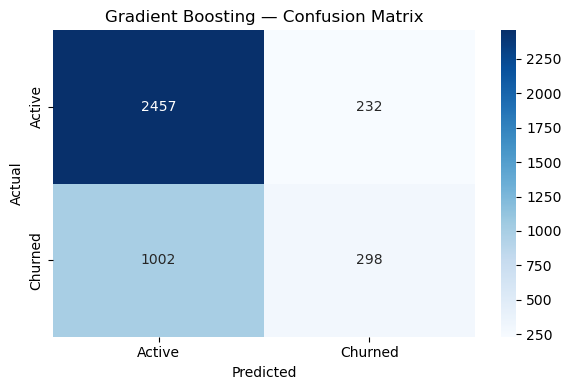

In [13]:
# ── Best Model Evaluation ─────────────────────────────────

best_name  = 'Gradient Boosting'
best       = results[best_name]

print(f"=== {best_name} ===\n")
print(classification_report(y_test, best['y_pred'], 
                             target_names=['Active', 'Churned']))

# Confusion matrix
cm = confusion_matrix(y_test, best['y_pred'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active', 'Churned'],
            yticklabels=['Active', 'Churned'])
plt.title(f'{best_name} — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../outputs/week3_confusion_matrix.png', dpi=150)
plt.show()

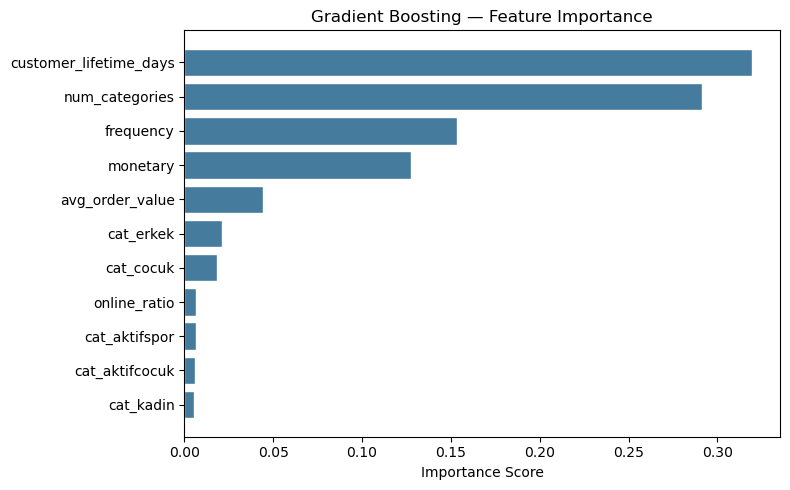

                   feature  importance
4   customer_lifetime_days    0.319324
5           num_categories    0.291175
0                frequency    0.153573
1                 monetary    0.127687
3          avg_order_value    0.044371
7                cat_erkek    0.021408
8                cat_cocuk    0.018227
2             online_ratio    0.006622
9            cat_aktifspor    0.006362
10          cat_aktifcocuk    0.006055
6                cat_kadin    0.005197


In [14]:
# ── Feature Importance ────────────────────────────────────

gb_model = results['Gradient Boosting']['model']
feature_names = X.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['feature'], importance_df['importance'], 
         color='#457B9D', edgecolor='white')
plt.title('Gradient Boosting — Feature Importance')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/week3_feature_importance.png', dpi=150)
plt.show()

print(importance_df)

In [15]:
# ── Churn Probability Scores ──────────────────────────────

data['churn_probability'] = results['Gradient Boosting']['y_proba'].tolist() + \
                             [None] * (len(data) - len(results['Gradient Boosting']['y_proba']))

# Cleaner approach: predict on full dataset
data['churn_probability'] = results['Gradient Boosting']['model'].predict_proba(
    scaler.transform(X)
)[:, 1]

data['churn_risk'] = pd.cut(data['churn_probability'],
                             bins=[0, 0.3, 0.6, 1.0],
                             labels=['Low Risk', 'Medium Risk', 'High Risk'])

print("Churn risk distribution:")
print(data['churn_risk'].value_counts())
print()

# Save
data.to_csv('../data/flo_final.csv', index=False)
print("Saved → flo_final.csv")

Churn risk distribution:
churn_risk
Medium Risk    11297
Low Risk        8176
High Risk        472
Name: count, dtype: int64

Saved → flo_final.csv
